# Data Visualization, Preprocessing, and Statistical Analysis Lab

**Name:** Elkana Munganga  
**Course:** MSCS-634-M50 – Advanced Big Data and Data Mining  
**Assignment:** Data Visualization, Preprocessing, and Statistical Analysis Lab

In [33]:
import pandas as pd

data = {
    "Date": [
        "2026-01-01", "2026-01-02", "2026-01-03", "2026-01-04",
        "2026-01-05", "2026-01-06", "2026-01-07", "2026-01-08",
        "2026-01-09", "2026-01-10", "2026-01-11", "2026-01-12"
    ],
    "Product": [
        "Laptop", "Phone", "Tablet", "Laptop",
        "Phone", "Tablet", "Laptop", "Phone",
        "Tablet", "Laptop", "Phone", "Tablet"
    ],
    "Units_Sold": [5, 10, 7, 8, 12, 6, 9, 11, 5, 7, 10, 100],
    "Price": [1200, 800, 500, 1200, 800, 500, 1200, 800, 500, 1200, 800, 500],
    "Customer_Rating": [4.5, 4.2, 4.0, 4.7, None, 4.1, 4.6, 4.3, None, 4.8, 4.4, 3.9]
}

df = pd.DataFrame(data)
df["Date"] = pd.to_datetime(df["Date"])

df.head()

,Date,Product,Units_Sold,Price,Customer_Rating
0,2026-01-01,Laptop,5,1200,4.5
1,2026-01-02,Phone,10,800,4.2
2,2026-01-03,Tablet,7,500,4.0
3,2026-01-04,Laptop,8,1200,4.7
4,2026-01-05,Phone,12,800,NaN


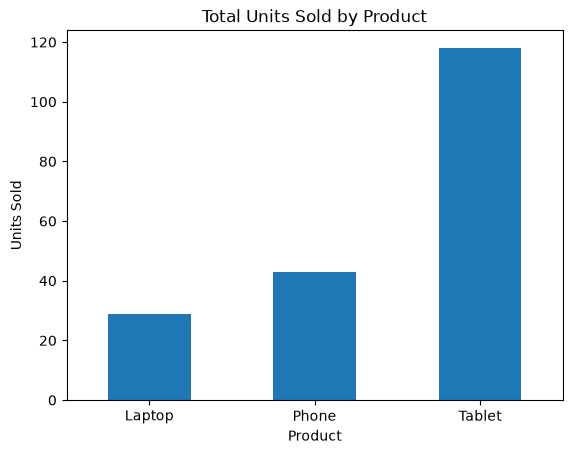

In [34]:
import matplotlib.pyplot as plt

product_sales = df.groupby("Product")["Units_Sold"].sum()

product_sales.plot(kind="bar")
plt.title("Total Units Sold by Product")
plt.xlabel("Product")
plt.ylabel("Units Sold")
plt.xticks(rotation=0)
plt.show()

### Bar Chart Insight
The bar chart compares total units sold for each product. Tablets have the highest total sales, mainly because the dataset contains an unusually high sales value that may be an outlier.

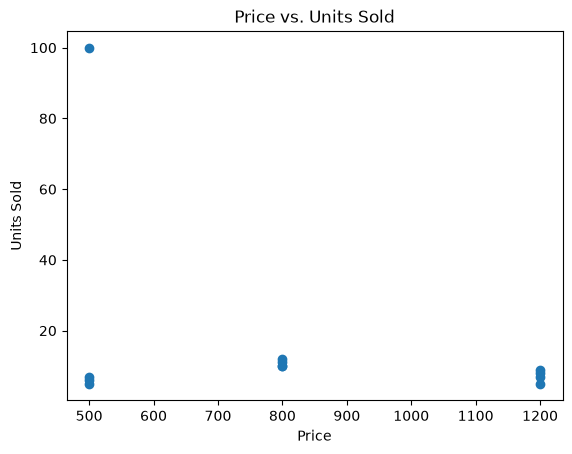

In [35]:
plt.scatter(df["Price"], df["Units_Sold"])
plt.title("Price vs. Units Sold")
plt.xlabel("Price")
plt.ylabel("Units Sold")
plt.show()

### Scatter Plot Insight
The scatter plot shows the relationship between product price and units sold. Most observations are grouped at lower sales quantities, while one value stands significantly above the others. This suggests that the dataset contains a possible outlier that should be investigated during preprocessing.

In [36]:
print("Missing values before cleaning:")
print(df.isnull().sum())

df[df["Customer_Rating"].isnull()]

Missing values before cleaning:
Date               0
Product            0
Units_Sold         0
Price              0
Customer_Rating    2
dtype: int64


,Date,Product,Units_Sold,Price,Customer_Rating
4,2026-01-05,Phone,12,800,NaN
8,2026-01-09,Tablet,5,500,NaN


In [37]:
mean_rating = df["Customer_Rating"].mean()

df["Customer_Rating"] = df["Customer_Rating"].fillna(mean_rating)

print("Mean rating used:", round(mean_rating, 2))
print("\nMissing values after cleaning:")
print(df.isnull().sum())

df.head(10)

Mean rating used: 4.35

Missing values after cleaning:
Date               0
Product            0
Units_Sold         0
Price              0
Customer_Rating    0
dtype: int64


,Date,Product,Units_Sold,Price,Customer_Rating
0,2026-01-01,Laptop,5,1200,4.50
1,2026-01-02,Phone,10,800,4.20
2,2026-01-03,Tablet,7,500,4.00
3,2026-01-04,Laptop,8,1200,4.70
4,2026-01-05,Phone,12,800,4.35
5,2026-01-06,Tablet,6,500,4.10
6,2026-01-07,Laptop,9,1200,4.60
7,2026-01-08,Phone,11,800,4.30
8,2026-01-09,Tablet,5,500,4.35
9,2026-01-10,Laptop,7,1200,4.80


### Handling Missing Values
The dataset contained two missing values in the Customer_Rating column. I replaced the missing values with the mean customer rating. This allows me to keep the records while providing a reasonable value based on the existing data.

In [38]:
Q1 = df["Units_Sold"].quantile(0.25)
Q3 = df["Units_Sold"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

outliers = df[
    (df["Units_Sold"] < lower_bound) |
    (df["Units_Sold"] > upper_bound)
]

print("\nIdentified Outliers:")
outliers

Q1: 6.75
Q3: 10.25
IQR: 3.5
Lower Bound: 1.5
Upper Bound: 15.5

Identified Outliers:


,Date,Product,Units_Sold,Price,Customer_Rating
11,2026-01-12,Tablet,100,500,3.9


In [39]:
df_clean = df[
    (df["Units_Sold"] >= lower_bound) &
    (df["Units_Sold"] <= upper_bound)
].copy()

print("Rows before outlier removal:", len(df))
print("Rows after outlier removal:", len(df_clean))

df_clean

Rows before outlier removal: 12
Rows after outlier removal: 11


,Date,Product,Units_Sold,Price,Customer_Rating
0,2026-01-01,Laptop,5,1200,4.50
1,2026-01-02,Phone,10,800,4.20
2,2026-01-03,Tablet,7,500,4.00
3,2026-01-04,Laptop,8,1200,4.70
4,2026-01-05,Phone,12,800,4.35
5,2026-01-06,Tablet,6,500,4.10
6,2026-01-07,Laptop,9,1200,4.60
7,2026-01-08,Phone,11,800,4.30
8,2026-01-09,Tablet,5,500,4.35
9,2026-01-10,Laptop,7,1200,4.80


### Outlier Detection
I used the IQR method to detect outliers in Units_Sold. The value 100 was identified as an outlier because it was above the calculated upper boundary. I removed this observation to prevent it from having an excessive effect on the analysis.

In [40]:
print("Dataset before reduction:")
print("Shape:", df_clean.shape)

df_clean

Dataset before reduction:
Shape: (11, 5)


,Date,Product,Units_Sold,Price,Customer_Rating
0,2026-01-01,Laptop,5,1200,4.50
1,2026-01-02,Phone,10,800,4.20
2,2026-01-03,Tablet,7,500,4.00
3,2026-01-04,Laptop,8,1200,4.70
4,2026-01-05,Phone,12,800,4.35
5,2026-01-06,Tablet,6,500,4.10
6,2026-01-07,Laptop,9,1200,4.60
7,2026-01-08,Phone,11,800,4.30
8,2026-01-09,Tablet,5,500,4.35
9,2026-01-10,Laptop,7,1200,4.80


In [41]:
df_reduced = df_clean.sample(frac=0.7, random_state=42)

df_reduced = df_reduced.drop(columns=["Date"])

print("Dataset after reduction:")
print("Shape:", df_reduced.shape)

df_reduced

Dataset after reduction:
Shape: (8, 4)


,Product,Units_Sold,Price,Customer_Rating
5,Tablet,6,500,4.10
0,Laptop,5,1200,4.50
9,Laptop,7,1200,4.80
10,Phone,10,800,4.40
2,Tablet,7,500,4.00
1,Phone,10,800,4.20
8,Tablet,5,500,4.35
4,Phone,12,800,4.35


### Data Reduction
I reduced the dataset by randomly sampling 70% of the cleaned records and removing the Date column. Sampling reduces the number of observations, while dimension reduction removes a column that is not necessary for the remaining analysis.

In [42]:
print("Before Scaling:")
df_reduced[["Price", "Units_Sold"]]

Before Scaling:


,Price,Units_Sold
5,500,6
0,1200,5
9,1200,7
10,800,10
2,500,7
1,800,10
8,500,5
4,800,12


In [43]:
df_scaled = df_reduced.copy()

# Min-Max Scaling
min_price = df_scaled["Price"].min()
max_price = df_scaled["Price"].max()

df_scaled["Price_Scaled"] = (
    (df_scaled["Price"] - min_price) /
    (max_price - min_price)
)

# Discretization
df_scaled["Sales_Category"] = pd.cut(
    df_scaled["Units_Sold"],
    bins=[0, 6, 9, float("inf")],
    labels=["Low", "Medium", "High"]
)

print("After Scaling and Discretization:")
df_scaled[["Price", "Price_Scaled", "Units_Sold", "Sales_Category"]]

After Scaling and Discretization:


,Price,Price_Scaled,Units_Sold,Sales_Category
5,500,0.000000,6,Low
0,1200,1.000000,5,Low
9,1200,1.000000,7,Medium
10,800,0.428571,10,High
2,500,0.000000,7,Medium
1,800,0.428571,10,High
8,500,0.000000,5,Low
4,800,0.428571,12,High


### Data Scaling and Discretization
I used Min-Max normalization to scale the Price column between 0 and 1. I also discretized Units_Sold into Low, Medium, and High sales categories. Scaling makes numerical values easier to compare, while discretization converts continuous numerical data into meaningful groups.

In [44]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             11 non-null     datetime64[us]
 1   Product          11 non-null     str           
 2   Units_Sold       11 non-null     int64         
 3   Price            11 non-null     int64         
 4   Customer_Rating  11 non-null     float64       
dtypes: datetime64[us](1), float64(1), int64(2), str(1)
memory usage: 572.0 bytes


In [45]:
df_clean.describe()

,Date,Units_Sold,Price,Customer_Rating
count,11,11.000000,11.000000,11.000000
mean,2026-01-06 00:00:00,8.181818,863.636364,4.390909
min,2026-01-01 00:00:00,5.000000,500.000000,4.000000
25%,2026-01-03 12:00:00,6.500000,650.000000,4.250000
50%,2026-01-06 00:00:00,8.000000,800.000000,4.350000
75%,2026-01-08 12:00:00,10.000000,1200.000000,4.550000
max,2026-01-11 00:00:00,12.000000,1200.000000,4.800000
std,NaN,2.400757,294.186088,0.245783


### General Overview
The info() function provides an overview of the dataset, including the number of records, columns, data types, and non-null values. The describe() function provides summary statistics for the numerical variables, including the mean, standard deviation, minimum, maximum, and quartiles.

In [46]:
minimum = df_clean["Units_Sold"].min()
maximum = df_clean["Units_Sold"].max()
mean = df_clean["Units_Sold"].mean()
median = df_clean["Units_Sold"].median()
mode = df_clean["Units_Sold"].mode().tolist()

print("Units Sold - Central Tendency")
print("Minimum:", minimum)
print("Maximum:", maximum)
print("Mean:", round(mean, 2))
print("Median:", median)
print("Mode:", mode)

Units Sold - Central Tendency
Minimum: 5
Maximum: 12
Mean: 8.18
Median: 8.0
Mode: [5, 7, 10]


### Central Tendency Measures
The minimum and maximum show the lowest and highest number of units sold. The mean represents the average sales, while the median represents the middle value. The mode identifies the value or values that occur most frequently in the dataset.

In [47]:
minimum = df_clean["Units_Sold"].min()
maximum = df_clean["Units_Sold"].max()

data_range = maximum - minimum
Q1 = df_clean["Units_Sold"].quantile(0.25)
Q3 = df_clean["Units_Sold"].quantile(0.75)
IQR = Q3 - Q1
variance = df_clean["Units_Sold"].var()
std_dev = df_clean["Units_Sold"].std()

print("Units Sold - Dispersion Measures")
print("Range:", data_range)
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Variance:", round(variance, 2))
print("Standard Deviation:", round(std_dev, 2))

Units Sold - Dispersion Measures
Range: 7
Q1: 6.5
Q3: 10.0
IQR: 3.5
Variance: 5.76
Standard Deviation: 2.4


### Dispersion Measures
These measures show how spread out the Units_Sold values are. The range shows the difference between the minimum and maximum values, while the quartiles and IQR describe the spread of the middle portion of the data. Variance and standard deviation measure how much the sales values vary around the mean.

In [48]:
numeric_columns = df_clean.select_dtypes(include="number")

correlation_matrix = numeric_columns.corr()

print("Correlation Matrix:")
correlation_matrix

Correlation Matrix:


,Units_Sold,Price,Customer_Rating
Units_Sold,1.000000,0.066933,-0.039287
Price,0.066933,1.000000,0.873185
Customer_Rating,-0.039287,0.873185,1.000000


### Correlation Analysis
The correlation matrix shows the relationship between the numerical variables in the dataset. Values closer to 1 indicate a stronger positive relationship, values closer to -1 indicate a stronger negative relationship, and values closer to 0 indicate a weaker linear relationship.